<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula04a_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [101]:
X.shape, X_train.shape, X_test.shape

((178, 13), (142, 13), (36, 13))

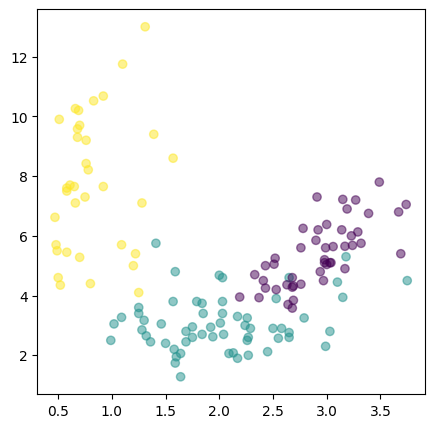

In [102]:
import matplotlib.pyplot as plt

def plotDataset(X, y):
  plt.figure(figsize=(5, 5))
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.viridis, alpha=0.5)

feats = [6, 9]
plotDataset(X_train[:, feats], y_train)

In [103]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import classification_report, confusion_matrix

class K1NN(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.X = X
    self.y = y
    return self

  def distance_(self, x):
    return np.sum((self.X - x)**2, axis=1)**0.5

  def predict(self, X):
    y_pred = np.empty((X.shape[0],))
    for i, x in enumerate(X):
      distances = self.distance_(x)
      min_idx = np.argmin(distances)
      y_pred[i] = self.y[min_idx]
    return y_pred

model = K1NN()
model.fit(X_train[:, feats], y_train)
y_pred = model.predict(X_test[:, feats])
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.91      0.95        11
           2       1.00      1.00      1.00        13

    accuracy                           0.97        36
   macro avg       0.97      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



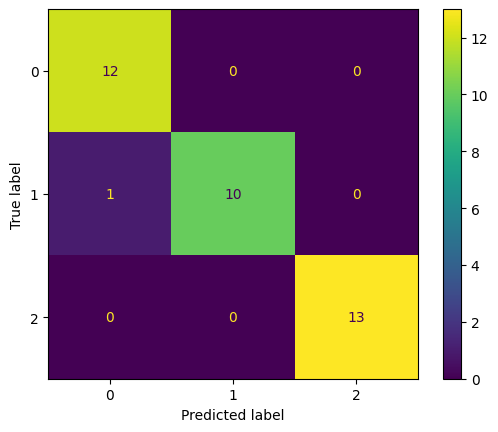

In [104]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [105]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train[:, feats], y_train)
y_pred = model.predict(X_test[:, feats])
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.91      0.95        11
           2       1.00      1.00      1.00        13

    accuracy                           0.97        36
   macro avg       0.97      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



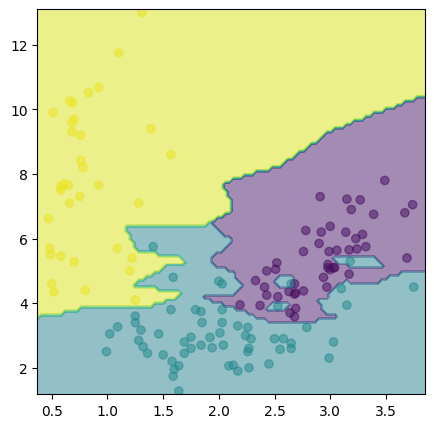

In [106]:
def defineAxes(X):
  offset = 0.1
  x_min, x_max = X[:, 0].min() - offset, X[:, 0].max() + offset
  y_min, y_max = X[:, 1].min() - offset, X[:, 1].max() + offset
  return x_min, x_max, y_min, y_max

def plotPredictions(model, X):
  axes = defineAxes(X)
  xs = np.linspace(axes[0], axes[1], 100)
  ys = np.linspace(axes[2], axes[3], 100)
  xx, yy = np.meshgrid(xs, ys)
  grid = np.c_[xx.ravel(), yy.ravel()]
  Z = model.predict(grid)
  plt.contourf(xx, yy, Z.reshape(xx.shape), cmap=plt.cm.viridis, alpha=0.5)

plotDataset(X_train[:, feats], y_train)
plotPredictions(model, X_train[:, feats])
plt.show()

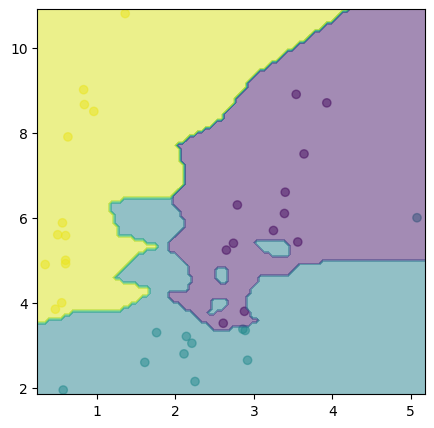

In [107]:
plotDataset(X_test[:, feats], y_test)
plotPredictions(model, X_test[:, feats])
plt.show()

              precision    recall  f1-score   support

           0       0.80      1.00      0.89        12
           1       1.00      0.73      0.84        11
           2       1.00      1.00      1.00        13

    accuracy                           0.92        36
   macro avg       0.93      0.91      0.91        36
weighted avg       0.93      0.92      0.91        36



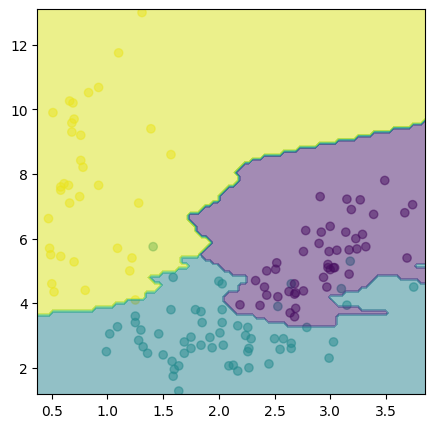

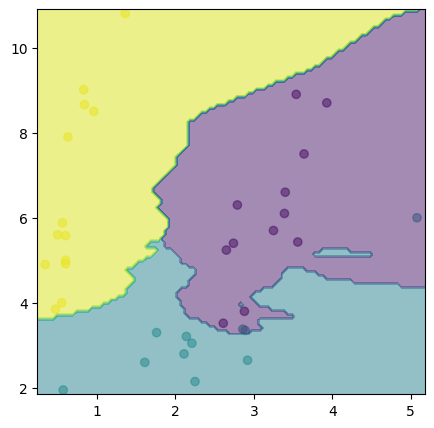

In [108]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train[:, feats], y_train)
y_pred = model.predict(X_test[:, feats])
print(classification_report(y_test, y_pred))
plotDataset(X_train[:, feats], y_train)
plotPredictions(model, X_train[:, feats])
plt.show()
plotDataset(X_test[:, feats], y_test)
plotPredictions(model, X_test[:, feats])
plt.show()

              precision    recall  f1-score   support

           0       0.80      1.00      0.89        12
           1       1.00      0.73      0.84        11
           2       1.00      1.00      1.00        13

    accuracy                           0.92        36
   macro avg       0.93      0.91      0.91        36
weighted avg       0.93      0.92      0.91        36



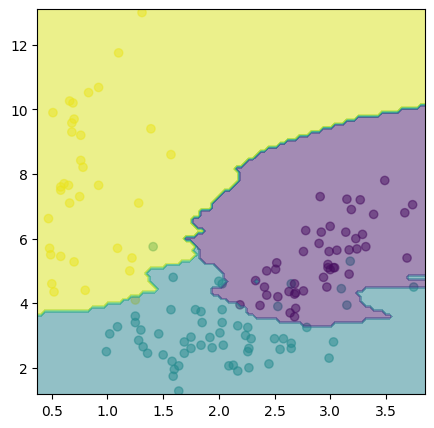

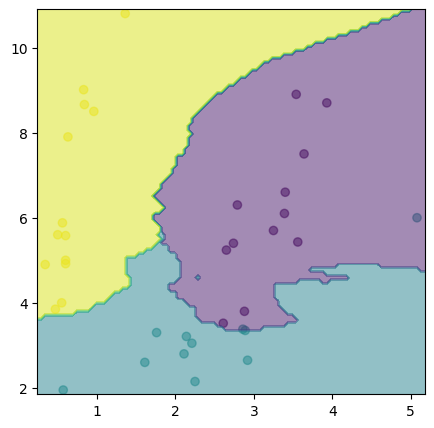

In [109]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train[:, feats], y_train)
y_pred = model.predict(X_test[:, feats])
print(classification_report(y_test, y_pred))
plotDataset(X_train[:, feats], y_train)
plotPredictions(model, X_train[:, feats])
plt.show()
plotDataset(X_test[:, feats], y_test)
plotPredictions(model, X_test[:, feats])
plt.show()

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        12
           1       0.77      0.91      0.83        11
           2       1.00      0.85      0.92        13

    accuracy                           0.89        36
   macro avg       0.90      0.89      0.89        36
weighted avg       0.90      0.89      0.89        36



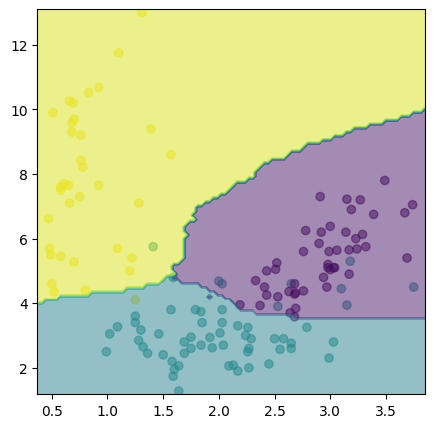

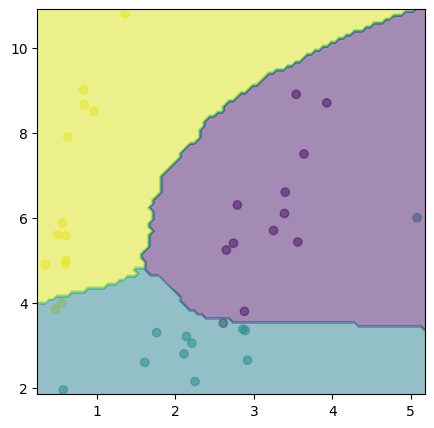

In [110]:
model = KNeighborsClassifier(n_neighbors=13)
model.fit(X_train[:, feats], y_train)
y_pred = model.predict(X_test[:, feats])
print(classification_report(y_test, y_pred))
plotDataset(X_train[:, feats], y_train)
plotPredictions(model, X_train[:, feats])
plt.show()
plotDataset(X_test[:, feats], y_test)
plotPredictions(model, X_test[:, feats])
plt.show()